# Donut 요소(Element) 파인튜닝 노트북

`donut_training_drawings.ipynb`(도면 전체 → JSON)를 **element 크롭 단위**로 바꾼 버전입니다.

- **입력**: YOLO-OBB 가 검출·정렬(rectify)한 element 크롭 (치수 / 공차 / GD&T / 거칠기)
- **정답**: `{"<type>": "<value>"}`  (예: `{"dimension": "Ø65"}`)
- **단일 task token `<s_element>`** — 타입 토큰(`<s_dimension>` 등)은 라벨에서 자동 등록됩니다.

> **데이터 준비**: `detection/cvat_to_donut.py` 로 CVAT export → `data/elements/{images,labels}` 생성 → 아래 split 셀 실행.
> **커널**: `kardi_env` (검출 YOLO + 인식 Donut 의존성이 모두 설치된 단일 커널 — 커널 전환 불필요).

## 파인튜닝 핵심 개념 (요약)

### 전체 흐름

```
    [element 크롭]                    [정답 JSON]
           │                               │
           ▼                               ▼
  ┌─────────────────┐           ┌──────────────────┐
  │  DonutProcessor │           │   json2token()   │
  │  resize / norm  │           │   dict → token   │
  └────────┬────────┘           └────────┬─────────┘
           │ pixel_values                │ target_seq
           └──────────────┬──────────────┘
                          ▼
       ╔══════════════════════════════════════╗
       ║      VisionEncoderDecoderModel       ║
       ║   Swin-T (Encoder) → BART (Decoder)  ║
       ╚═════════════════╤════════════════════╝
                         ▼  logits
                  CrossEntropyLoss → 역전파
```

### 구성 요소 한 줄 정리

| 구성 | 역할 |
|:---|:---|
| **DonutProcessor** | 크롭 이미지 → 리사이즈(`384×384`)·정규화(`[-1,1]`) → `pixel_values` |
| **Swin-T** (encoder) | 이미지 → 시각 특징 |
| **BART** (decoder) | 시각 특징 + 이전 토큰 → 다음 토큰 |
| **json2token / token2json** | dict ↔ `<s_key>값</s_key>` 토큰 상호 변환 |

### 학습 방식 & loss (핵심만)

- **Teacher Forcing**: 학습 땐 이전 *정답* 토큰을 입력으로 줘 안정·빠르게 학습. (추론 땐 이전 *예측* 토큰을 사용)
- **Loss**: 정답 토큰을 맞히는 CrossEntropy. 라벨의 **패딩 위치는 `-100`** 으로 마스킹해 loss 에서 제외.
- **과적합 점검**: `train_loss`는 계속 ↘ 인데 `eval_loss`가 ↗ 로 돌아서면 과적합.
  → `EarlyStoppingCallback` 이 best 지점에서 학습 중단, `load_best_model_at_end` 가 best 가중치 복원.

In [1]:
# ── widget 렌더러 오류 방지 (VS Code Jupyter) ─────────────────────
# tqdm.auto 및 HuggingFace 내부 progress bar가 ipywidget을
# 사용하지 않도록 강제합니다 — 텍스트 모드로 출력됩니다.
import os
os.environ['TQDM_NOTEBOOK'] = 'false'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # tokenizer 경고 억제

# ── Step 0: 환경 확인 ──────────────────────────────────────────────
# 학습에 필요한 라이브러리 버전과 GPU 상태를 먼저 점검합니다.
# CUDA가 False이면 GPU를 인식하지 못한 것 — 드라이버/환경을 확인하세요.
import torch
import transformers
import platform

print(f"Python     : {platform.python_version()}")
print(f"PyTorch    : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA 사용   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Python     : 3.10.19
PyTorch    : 2.11.0+cu130
Transformers: 4.57.6
CUDA 사용   : True
GPU        : NVIDIA GB10
VRAM       : 130.7 GB


In [2]:
# ── 필수 패키지 설치 확인 ─────────────────────────────────────────
# 이미 설치된 경우 무시됩니다 — 매번 실행해도 안전합니다.
# datasets  : HuggingFace 데이터셋 다운로드 라이브러리
# sentencepiece : Donut 토크나이저가 내부적으로 사용하는 형태소 분석기
import importlib, subprocess, sys

required = {"datasets": "datasets", "sentencepiece": "sentencepiece"}
missing  = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]

if missing:
    print(f"설치 중: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])
    print("설치 완료 — 커널을 재시작하지 않아도 됩니다.")
else:
    print("모든 패키지 설치 확인 ✓")


모든 패키지 설치 확인 ✓


In [3]:
# ── 공통 Import ───────────────────────────────────────────────────
import json       # JSON 파일 읽기/쓰기
import os         # 파일 경로, 디렉터리 생성
import random     # 데이터셋 셔플 및 시드 고정
import re         # 정규표현식 (토큰 파싱에 사용)
import shutil
from pathlib import Path  # 운영체제 독립적인 파일 경로 처리

import numpy as np         # 수치 연산 및 시드 고정
from PIL import Image      # 이미지 파일 열기/변환
# tqdm.auto는 VS Code Jupyter에서 ipywidget 오류를 유발하므로 tqdm 직접 사용
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader  # 커스텀 데이터셋 클래스

from transformers import (
    DonutProcessor,              # 이미지 전처리 + 텍스트 토크나이저 통합 유틸리티
    VisionEncoderDecoderModel,   # 인코더(Swin-T) + 디코더(BART) 통합 모델
    Seq2SeqTrainer,              # Seq2Seq 학습 자동화 (forward/backward/저장)
    Seq2SeqTrainingArguments,    # 학습 하이퍼파라미터 설정
)

# ── matplotlib 전역 스타일 설정 ────────────────────────────────────
# 흰 배경에서도 텍스트/축/선이 선명하게 보이도록 전역 적용
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.facecolor": "white",   # 그림 배경 흰색
    "axes.facecolor":   "white",   # 축 영역 배경 흰색
    "savefig.facecolor":"white",   # 저장 시에도 흰 배경
    "text.color":       "black",   # 모든 텍스트 검정
    "axes.labelcolor":  "black",   # 축 레이블 검정
    "xtick.color":      "black",   # x축 눈금 검정
    "ytick.color":      "black",   # y축 눈금 검정
    "axes.edgecolor":   "black",   # 축 테두리 검정
})

# ── 한글 폰트 설정 (plot 한글 깨짐 / Glyph 경고 방지) ──────────────
# 시스템의 Noto Sans CJK(KR 포함)를 등록해 matplotlib 기본 폰트로 사용
from matplotlib import font_manager as _fm
_ko_font = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
try:
    _fm.fontManager.addfont(_ko_font)
    matplotlib.rcParams["font.family"] = _fm.FontProperties(fname=_ko_font).get_name()
except Exception as _e:
    print("한글 폰트 등록 실패(영문만 표시됨):", _e)
matplotlib.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("Import 완료 ✓  (한글 폰트:", matplotlib.rcParams["font.family"], ")")


Import 완료 ✓  (한글 폰트: ['Noto Sans CJK JP'] )


## Step 1 – 설정 (Configuration)

모든 하이퍼파라미터를 딕셔너리로 관리합니다.  
`dataset_name`을 `None`으로 바꾸고 `local_train_dir` / `local_val_dir`을 지정하면 커스텀 데이터셋을 사용할 수 있습니다.

In [4]:
# ── Step 1: 설정 (Element Donut 파인튜닝용) ───────────────
# YOLO 가 검출·분류한 element 크롭을 입력으로, 그 요소값을 출력하도록 Donut base 를 파인튜닝.
#
# ★ 단일 모델 + 단일 task token(<s_element>) 설계:
#   라벨 JSON 을 {"<type>": "<value>"} 형태로 두면(예: {"dimension": "Ø65"}),
#   build_model_and_processor 가 라벨에서 <s_dimension>/<s_tolerance>/... 토큰을 자동 등록합니다.
#   추론 시 YOLO 가 type 을 이미 알므로 결과 검증/보정에 활용할 수 있습니다.
CFG = {
    "model": {
        "pretrained_model_name": "naver-clova-ix/donut-base",
        "max_length": 128,        # element 값은 짧음
        "image_size": [384, 384], # element 크롭은 작음 → 작은 해상도로 충분(메모리·속도 이득)
    },
    "data": {
        "dataset_name": None,                       # 로컬 모드
        "task_prompt": "<s_element>",
        "local_train_dir": "../data/processed_elements/train",
        "local_val_dir":   "../data/processed_elements/val",
    },
    "training": {
        "output_dir": "../checkpoints_elements",
        "num_epochs": 60,        # 상한값 — early_stopping_patience 로 더 일찍 종료됨
        "batch_size": 8,          # 작은 이미지 → 배치 확대 가능 (VRAM 부족 시 낮추기)
        "gradient_accumulation_steps": 2,
        "learning_rate": 3e-5,
        "warmup_steps": 50,
        "weight_decay": 0.01,
        "bf16": True,             # ★ fp16 은 Donut 에서 불안정 → bf16 고정
        "fp16": False,
        "save_steps": 50,
        "eval_steps": 50,
        "early_stopping_patience": 5,  # eval_loss 5회 연속 개선 없으면 조기 종료
        "logging_steps": 10,
        "dataloader_num_workers": 4,
        "seed": 42,
    },
    "wandb": {"enabled": False, "project": "donut-elements", "run_name": None},
}
print("Config (element) loaded ✓")
print(f"  태스크   : {CFG['data']['task_prompt']}")
print(f"  학습 출력: {CFG['training']['output_dir']}")

Config (element) loaded ✓
  태스크   : <s_element>
  학습 출력: ../checkpoints_elements


In [5]:
# ── 재현성을 위한 시드 고정 ────────────────────────────────────────
# 동일한 시드를 설정하면 같은 코드를 다시 실행해도 동일한 결과가 나옵니다.
# Python / NumPy / PyTorch / CUDA 각각의 난수 생성기를 모두 고정해야 합니다.
def set_seed(seed: int):
    random.seed(seed)        # Python 기본 random 모듈
    np.random.seed(seed)     # NumPy 난수
    torch.manual_seed(seed)  # CPU 연산 난수
    torch.cuda.manual_seed_all(seed)  # GPU 연산 난수 (멀티GPU 포함)

set_seed(CFG["training"]["seed"])
print(f"Seed = {CFG['training']['seed']} 고정 완료")


Seed = 42 고정 완료


## Element 데이터셋 준비 (train/val 분리)

`data/elements/{images,labels}` (crop PNG + `{"<type>":"<value>"}` JSON) 을
`data/processed_elements/{train,val}` 로 분리합니다. 라벨은 `detection/cvat_to_donut.py` 로 CVAT export 에서 생성.

In [6]:
# ── element 데이터 train/val 분리 ─────────────────
import shutil, random
from pathlib import Path

SRC = Path("../data/elements")
OUT = Path("../data/processed_elements")
VAL_RATIO, SEED = 0.1, CFG["training"]["seed"]

img_dir, lbl_dir = SRC / "images", SRC / "labels"
stems = sorted(p.stem for p in img_dir.glob("*.png")
               if (lbl_dir / (p.stem + ".json")).exists())
assert stems, f"{SRC} 에 crop+label 쌍이 없습니다 — cvat_to_donut.py 를 먼저 실행하세요"
random.Random(SEED).shuffle(stems)
n_val = max(1, int(len(stems) * VAL_RATIO))
splits = {"val": stems[:n_val], "train": stems[n_val:]}
for split, names in splits.items():
    for sub in ("images", "labels"):
        (OUT / split / sub).mkdir(parents=True, exist_ok=True)
    for st in names:
        shutil.copy(img_dir / f"{st}.png",  OUT / split / "images" / f"{st}.png")
        shutil.copy(lbl_dir / f"{st}.json", OUT / split / "labels" / f"{st}.json")
print({k: len(v) for k, v in splits.items()})

{'val': 197, 'train': 1778}


## Step 2 – 모델 & 프로세서 로드

- **DonutProcessor**: 이미지 전처리(resize/normalize) + 토크나이저
- **VisionEncoderDecoderModel**: 인코더(Swin-T) + 디코더(BART)

task token `<s_element>` 와 **라벨의 모든 타입 토큰**(`<s_dimension>` 등)을 토크나이저에 추가하고 임베딩을 확장합니다.
타입 토큰은 **train+val 라벨에서 모아 등록** — 희소 타입(예: roughness)이 한쪽 split 에만 있어도 누락되지 않습니다.

In [7]:
# ── Step 2: 모델 & 프로세서 빌드 ─────────────────────────────────
def build_model_and_processor(cfg):
    model_cfg  = cfg["model"]
    name       = model_cfg["pretrained_model_name"]
    image_size = model_cfg["image_size"]   # [height, width]
    max_length = model_cfg["max_length"]

    # HuggingFace Hub에서 사전학습된 가중치와 설정을 다운로드합니다.
    # 처음 실행 시 모델 파일이 캐시(~/.cache/huggingface)에 저장되므로
    # 이후 실행부터는 인터넷 연결 없이도 동작합니다.
    processor = DonutProcessor.from_pretrained(name)
    model     = VisionEncoderDecoderModel.from_pretrained(name)

    # ── 인코더 입력 해상도 재설정 ──────────────────────────────────
    # 사전학습 해상도와 다를 경우, 프로세서와 모델 config를 모두 변경해야
    # 실제 forward pass에서 이미지 크기가 일치합니다.
    # 프로세서: 이미지를 리사이즈할 때 사용할 목표 크기
    processor.image_processor.size = {"height": image_size[0], "width": image_size[1]}
    # do_align_long_axis=False: 세로 이미지를 회전하지 않고 그대로 사용
    processor.image_processor.do_align_long_axis = False
    # 모델 config: 인코더가 실제로 처리할 해상도와 디코더 최대 길이 반영
    model.config.encoder.image_size = image_size
    model.config.decoder.max_length = max_length

    # ── 태스크 토큰 + 필드 토큰을 토크나이저에 추가 ───────────────
    # Donut은 특수 토큰으로 태스크와 JSON 필드를 구분합니다.
    #  (1) task_prompt : 디코더 시작 토큰 (예: <s_element>)
    #  (2) 필드 토큰   : 라벨 JSON의 모든 키 → <s_{key}> / </s_{key}> 와 <sep/>
    # ★ 필드 토큰을 special token으로 등록하지 않으면 필드명이 subword로 쪼개져
    #   학습이 거의 안 됩니다(깨진 출력의 핵심 원인). 반드시 함께 추가하세요.
    task_prompt = cfg["data"]["task_prompt"]

    def _collect_keys(obj, ks):
        if isinstance(obj, dict):
            for k, v in obj.items():
                ks.add(k); _collect_keys(v, ks)
        elif isinstance(obj, list):
            for v in obj:
                _collect_keys(v, ks)

    keys = set()
    # train + val 양쪽 라벨에서 키 수집 — 희소 타입(예: roughness)이 train split 에
    # 한 개도 안 들어가면 토큰 미등록 → 디코더가 그 키를 영영 못 만듦. (등록은 어휘 정의일 뿐 누수 아님)
    for _split_dir in (cfg["data"]["local_train_dir"], cfg["data"]["local_val_dir"]):
        for f in sorted((Path(_split_dir) / "labels").glob("*.json")):
            _collect_keys(json.load(open(f, encoding="utf-8")), keys)
    field_tokens = []
    for k in sorted(keys):
        field_tokens += [f"<s_{k}>", f"</s_{k}>"]

    special_tokens = list(dict.fromkeys([task_prompt, "<sep/>"] + field_tokens))
    num_added = processor.tokenizer.add_special_tokens(
        {"additional_special_tokens": special_tokens}
    )

    # ── (추가) 값에 등장하는 도면/GD&T 기호를 '일반' 토큰으로 등록 ───────
    # 값(value) 안의 ⊥ ∡ ∥ … 는 '구조'가 아니라 '내용' → add_tokens 사용.
    # (add_special_tokens 로 넣으면 skip_special_tokens 디코딩에서 사라져 값이 잘림)
    # base 토크나이저(SentencePiece)에 이 글자들이 없어 <unk> 로 나오던 문제를 해결.
    GDNT_SYMBOLS = [
        # 기하공차 기호
        "⊥", "∥", "∠", "∡", "⟂", "○", "◎", "⌒", "⌓", "⏤", "⏥",
        "⌭", "⌯", "⌖", "⌰", "△", "↗",
        # 치수 / 한정자
        "Ø", "⌀", "±", "°", "√", "∞", "×",
        # ※ 재질조건 원형기호 Ⓜ Ⓛ Ⓟ Ⓢ Ⓕ Ⓣ 는 일부러 제외한다:
        #   NFKC 정규화로 평문 M L P S F T 와 충돌(추가 시 "TOP"→"ⓉOⓅ" 처럼 오염)하고,
        #   base 토크나이저가 이미 Ⓜ→M 로 정규화하므로 어차피 원형기호를 살릴 수 없다.
        # 가공 기호
        "⌴", "⌵", "↧", "⊘", "↓",
    ]
    # ★ ASCII 숫자 0-9 를 '명시적으로' 추가 — 치수값의 핵심.
    #   donut-base SentencePiece 에는 '▁1'(공백 뒤)만 있고 문자열 중간의 '1'
    #   (예: "0.1" → ▁0 . <unk>)을 표현하는 조각이 없어 숫자가 <unk> 로 깨졌다.
    #   OOV 가 '컨텍스트 의존'이라 글자 단독 검사로는 못 잡으므로 숫자는 통째로 등록한다.
    ASCII_DIGITS = list("0123456789")
    # ★ 데이터 라벨을 실제로 토크나이즈해 <unk> 로 깨지는 글자를 자동 수집(목록 누락 방지).
    #   값 전체를 인코딩해 unk 가 나온 값의 글자들을 후보로 본 뒤, '0c0' 미드-스트링
    #   컨텍스트로 재확인해 위 큐레이션/숫자에 없던 OOV(예: Т, ━, ↓ …)만 추려 더한다.
    unk_id = processor.tokenizer.unk_token_id
    def _is_oov(ch):  # 앞뒤에 글자를 붙인 미드-스트링 컨텍스트로 OOV 판정
        return unk_id in processor.tokenizer.encode("0" + ch + "0", add_special_tokens=False)
    label_chars = set()
    for _sd in (cfg["data"]["local_train_dir"], cfg["data"]["local_val_dir"]):
        for _f in (Path(_sd) / "labels").glob("*.json"):
            for _v in json.load(open(_f, encoding="utf-8")).values():
                label_chars.update(str(_v))
    auto_oov = [
        c for c in label_chars
        if not c.isspace() and _is_oov(c)
        and c not in {"\ufffd", "\ufe0f"}   # 깨진 문자·변이선택자는 제외(라벨 정제 대상)
    ]
    # 안전장치: NFKC 로 모양이 바뀌는 글자는 추가하지 않는다. base 토크나이저가 입력을
    #   정규화하므로, 정규화 결과가 흔한 글자(M/L/…)와 겹치면 그 평문까지 오염된다.
    import unicodedata as _ud
    value_tokens = [c for c in dict.fromkeys(GDNT_SYMBOLS + ASCII_DIGITS + auto_oov)
                    if _ud.normalize("NFKC", c) == c]
    n_val_added = processor.tokenizer.add_tokens(value_tokens)   # ← 일반 토큰으로 등록

    # 특수(구조) 토큰 또는 값 기호 중 하나라도 추가됐으면 임베딩 레이어 확장
    if num_added or n_val_added:
        model.decoder.resize_token_embeddings(len(processor.tokenizer))
    print(f"special token 추가: {num_added}개 (task 1 + 필드 키 {len(keys)}종)")
    print(f"값 기호 토큰 추가 : {n_val_added}개 (자동탐지 OOV {len(auto_oov)}종 포함)")

    # ── 디코더 시작/패딩 토큰 연결 ────────────────────────────────
    # pad_token_id : 배치 내 길이를 맞추기 위한 패딩 토큰 ID
    # decoder_start_token_id : 디코더가 생성을 시작할 때 첫 입력으로 사용하는 토큰
    #   → task_prompt("<s_element>")가 첫 토큰이 되어 태스크를 인식합니다
    model.config.pad_token_id           = processor.tokenizer.pad_token_id
    model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(
        [task_prompt]
    )[0]

    return model, processor


model, processor = build_model_and_processor(CFG)

# GPU가 있으면 GPU로, 없으면 CPU로 모델을 이동
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

enc_params = sum(p.numel() for p in model.encoder.parameters()) / 1e6
dec_params = sum(p.numel() for p in model.decoder.parameters()) / 1e6
print(f"디바이스       : {device}")
print(f"인코더 파라미터: {enc_params:.1f}M  (Swin Transformer — 이미지 특징 추출)")
print(f"디코더 파라미터: {dec_params:.1f}M  (BART — 토큰 시퀀스 생성)")
print(f"Decoder start token: {processor.tokenizer.convert_ids_to_tokens([model.config.decoder_start_token_id])}")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


special token 추가: 12개 (task 1 + 필드 키 5종)
값 기호 토큰 추가 : 41개 (자동탐지 OOV 11종 포함)
디바이스       : cuda
인코더 파라미터: 74.2M  (Swin Transformer — 이미지 특징 추출)
디코더 파라미터: 127.7M  (BART — 토큰 시퀀스 생성)
Decoder start token: ['<s_element>']


## Step 3 – 데이터셋 구성 & 시각화

### DonutDataset 동작 원리

| 입력 | 처리 | 출력 |
|------|------|------|
| PIL Image | DonutProcessor → pixel_values | `(C, H, W)` Tensor |
| JSON ground truth | Tokenizer → teacher-forcing label | `(max_length,)` Token IDs |

**패딩 토큰 → -100**: CrossEntropyLoss는 `-100`으로 표시된 위치를 자동으로 무시합니다 (패딩 위치에서 loss 계산 안 함).

### 이 노트북의 데이터셋

로컬 element 크롭만 사용합니다 (`CFG.data.dataset_name = None`):

- `local_train_dir` / `local_val_dir` = `data/processed_elements/{train,val}`
- 라벨 = element 1개당 `{"<type>": "<value>"}` 한 쌍 (예: `{"dimension": "Ø65"}`)

> `dataset_name` 에 HuggingFace ID(예: `naver-clova-ix/cord-v2`)와 그에 맞는 `task_prompt` 를 넣으면
> 공개 데이터셋으로도 학습할 수 있지만, 이 노트북의 목적은 **도면 element 인식**입니다.

In [8]:
# ── Step 3a: DonutDataset 정의 ────────────────────────────────────

def json2token(obj, sort_keys=True):
    '''dict/list → Donut 토큰 시퀀스 변환.

    Donut의 정답은 JSON을 XML 스타일 토큰으로 표현합니다.
    예) {"total": "12500"} → <s_total>12500</s_total>
        {"items": [{"nm": "A"}]} → <s_items><s_nm>A</s_nm></s_items>

    sort_keys=True : 키를 역순 정렬하여 항상 동일한 순서를 보장합니다.
    '''
    if isinstance(obj, dict):
        output = ""
        keys = sorted(obj.keys(), reverse=True) if sort_keys else obj.keys()
        for k in keys:
            # 재귀 호출로 중첩 dict/list도 처리
            output += f"<s_{k}>" + json2token(obj[k], sort_keys) + f"</s_{k}>"
        return output
    elif isinstance(obj, list):
        # 리스트 항목은 <sep/> 토큰으로 구분
        return "<sep/>".join([json2token(v, sort_keys) for v in obj])
    else:
        return str(obj)


class DonutDataset(Dataset):
    '''HuggingFace 데이터셋 split 또는 로컬 디렉터리를 Donut 학습용으로 변환.

    로컬 디렉터리 레이아웃:
        <root>/
            images/   *.png / *.jpg
            labels/   *.json   (이미지와 동일한 파일명 stem)
    '''

    def __init__(self, dataset_or_root, processor, max_length: int, task_prompt: str):
        self.processor   = processor
        self.max_length  = max_length
        self.task_prompt = task_prompt

        # 입력 타입에 따라 HuggingFace 모드 / 로컬 모드를 자동 선택
        if isinstance(dataset_or_root, (str, Path)):
            self.samples = self._load_local(Path(dataset_or_root))
            self.mode    = "local"
        else:
            self.hf_dataset = dataset_or_root
            self.mode       = "hf"

    def _load_local(self, root: Path):
        # images/와 labels/ 폴더에서 같은 파일명을 가진 쌍을 찾아 리스트로 반환
        image_exts = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}
        samples = []
        for img_path in sorted((root / "images").glob("*")):
            if img_path.suffix.lower() not in image_exts:
                continue
            label_path = root / "labels" / (img_path.stem + ".json")
            if label_path.exists():
                samples.append((img_path, label_path))
        return samples

    def __len__(self):
        return len(self.hf_dataset) if self.mode == "hf" else len(self.samples)

    def __getitem__(self, idx):
        # ── 이미지와 정답 시퀀스 준비 ────────────────────────────
        if self.mode == "hf":
            sample = self.hf_dataset[idx]
            image  = sample["image"].convert("RGB")
            gt     = json.loads(sample["ground_truth"])
            if "gt_parse" in gt:
                # gt_parse는 이미 dict → json2token()으로 토큰 시퀀스 변환
                # 예(HF CORD): <s_cord-v2><s_total>12500</s_total>...</s_cord-v2>EOS
                target_seq = (
                    self.task_prompt
                    + json2token(gt["gt_parse"])
                    + self.processor.tokenizer.eos_token  # 문장 끝 토큰
                )
            else:
                target_seq = self.task_prompt + self.processor.tokenizer.eos_token
        else:
            img_path, label_path = self.samples[idx]
            image = Image.open(img_path).convert("RGB")
            with open(label_path) as f:
                gt = json.load(f)
            target_seq = (
                self.task_prompt
                + json2token(gt)
                + self.processor.tokenizer.eos_token
            )

        # ── 이미지 → pixel_values ────────────────────────────────
        # DonutProcessor가 이미지를 지정 해상도로 리사이즈하고
        # 픽셀 값을 [-1, 1] 범위로 정규화합니다.
        # squeeze(0): 배치 차원 제거 → (1, C, H, W) → (C, H, W)
        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        # ── 정답 텍스트 → label token IDs ────────────────────────
        # Teacher Forcing 학습을 위해 정답 시퀀스를 토큰 ID로 변환합니다.
        # padding="max_length" : 짧은 시퀀스를 max_length까지 패딩 토큰으로 채움
        # truncation=True      : max_length를 초과하면 잘라냄
        labels = self.processor.tokenizer(
            target_seq,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        # 패딩 위치를 -100으로 마스킹
        # CrossEntropyLoss는 target=-100인 위치를 자동으로 무시합니다.
        # 즉, 의미 없는 패딩 토큰에서는 loss가 계산되지 않습니다.
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values":    pixel_values,   # 모델 입력 이미지
            "labels":          labels,          # Teacher Forcing 정답 레이블
            "target_sequence": target_seq,      # 평가 시 문자열 비교용
        }

print("DonutDataset 클래스 정의 완료 ✓")


DonutDataset 클래스 정의 완료 ✓


In [9]:
# ── Step 3b: 데이터셋 로드 ────────────────────────────────────────
# CFG 설정에 따라 HuggingFace 또는 로컬 디렉터리에서 데이터를 로드합니다.
# dataset_name이 지정되면 인터넷에서 자동 다운로드하고,
# None이면 local_train_dir / local_val_dir 경로를 사용합니다.
def build_datasets(cfg, processor):
    data_cfg   = cfg["data"]
    max_length = cfg["model"]["max_length"]
    prompt     = data_cfg["task_prompt"]

    if data_cfg.get("dataset_name"):          # HuggingFace 데이터셋
        from datasets import load_dataset
        # load_dataset은 처음 실행 시 다운로드 후 로컬에 캐시합니다
        raw      = load_dataset(data_cfg["dataset_name"])
        train_ds = DonutDataset(raw[data_cfg["train_split"]], processor, max_length, prompt)
        val_ds   = DonutDataset(raw[data_cfg["val_split"]],   processor, max_length, prompt)
    else:                                      # 로컬 디렉터리
        train_ds = DonutDataset(data_cfg["local_train_dir"], processor, max_length, prompt)
        val_ds   = DonutDataset(data_cfg["local_val_dir"],   processor, max_length, prompt)

    return train_ds, val_ds


train_ds, val_ds = build_datasets(CFG, processor)
print(f"Train 샘플 수: {len(train_ds):,}")
print(f"Val   샘플 수: {len(val_ds):,}")


Train 샘플 수: 1,778
Val   샘플 수: 197


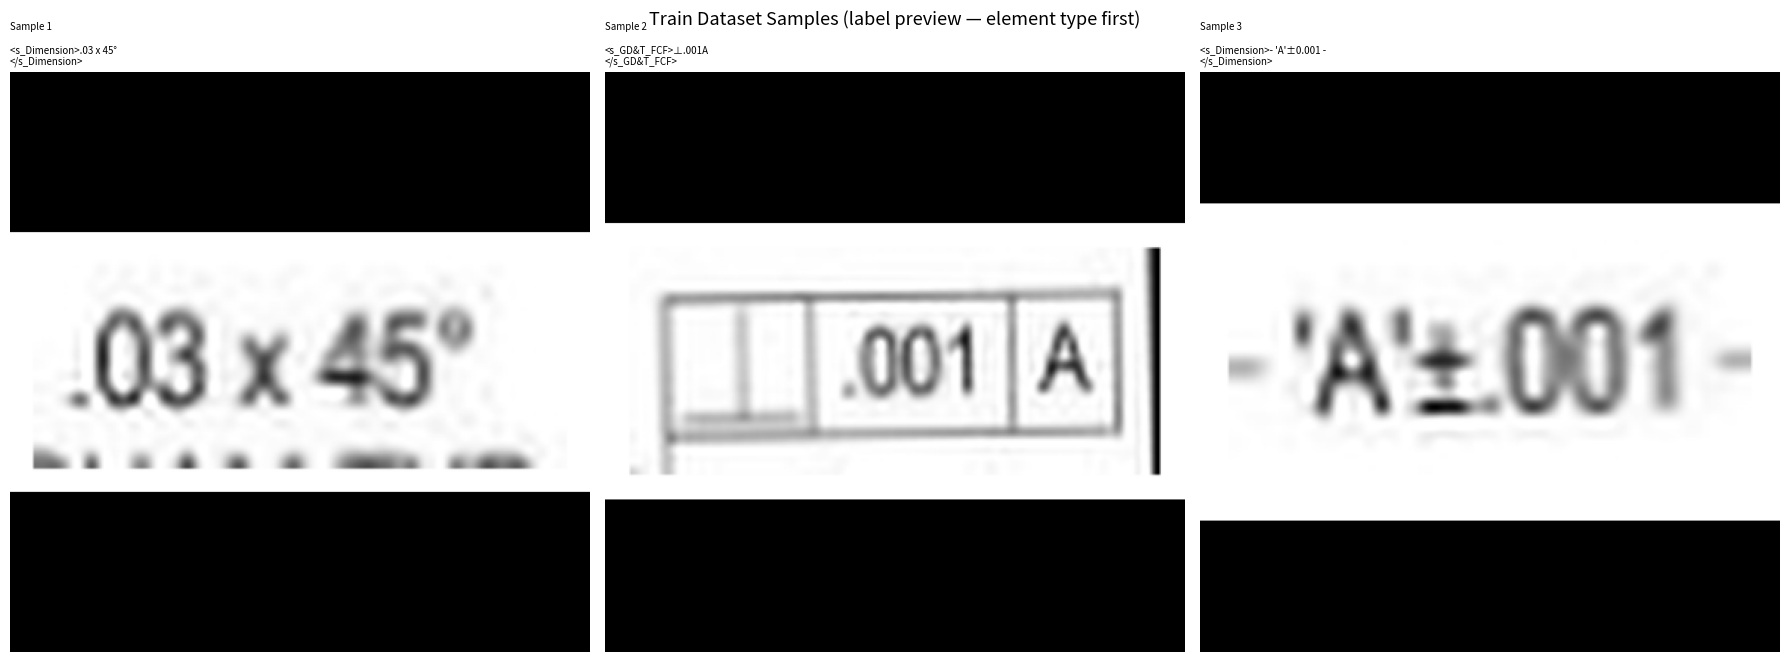


샘플 1 — 유효 토큰 수: 13 / 128
  (나머지 115개는 패딩 — loss 계산 제외)


In [10]:
# ── Step 3c: 샘플 시각화 ──────────────────────────────────────────
# 학습 데이터가 올바르게 로드됐는지 눈으로 확인합니다.
# 라벨(정답)을 element 타입(dimension/tolerance/gdt/roughness) 우선 순서로 표시합니다.
# (target_sequence는 json2token이 키를 역순 정렬해 샘플마다 앞 필드가 달라지므로,
#  미리보기는 아래 PREVIEW_ORDER로 다시 정렬해 일관되게 보여줍니다.)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

PREVIEW_ORDER = ["dimension", "tolerance", "gdt", "roughness"]
PREVIEW_CHARS = 220   # 표시할 토큰 문자 수 (이전 80 → 220)

def preview_seq(label: dict) -> str:
    # PREVIEW_ORDER에 있는 키를 먼저, 그 외 키는 뒤에 붙여 토큰화
    keys = [k for k in PREVIEW_ORDER if k in label] + \
           [k for k in label if k not in PREVIEW_ORDER]
    s = "".join(f"<s_{k}>" + json2token(label[k]) + f"</s_{k}>" for k in keys)
    return s[:PREVIEW_CHARS]

for idx, ax in enumerate(axes):
    i = idx + 1  # 1,2,3번째 샘플을 출력
    sample = train_ds[i]

    # pixel_values는 [-1, 1]로 정규화되어 있으므로 [0, 1]로 되돌려 표시
    img_tensor = sample["pixel_values"]
    img_np     = (img_tensor.permute(1, 2, 0).numpy() + 1) / 2  # [-1,1] → [0,1]
    img_np     = img_np.clip(0, 1)
    ax.imshow(img_np)
    ax.axis("off")

    # 로컬 모드: 라벨 dict를 파일에서 직접 읽어 핵심 필드 우선으로 미리보기 구성
    if getattr(train_ds, "mode", "local") == "local":
        label    = json.load(open(train_ds.samples[i][1], encoding="utf-8"))
        gt_short = preview_seq(label)
    else:
        gt_short = sample["target_sequence"][:PREVIEW_CHARS]
    # "<" 앞에 줄바꿈을 넣어 토큰 구조를 읽기 쉽게
    gt_short = gt_short.replace("<", "\n<")
    ax.set_title(f"Sample {i}\n{gt_short}", fontsize=7, loc="left")

plt.suptitle("Train Dataset Samples (label preview — element type first)", fontsize=13)
plt.tight_layout()
plt.show()

# 유효 토큰 수 확인: -100이 아닌 위치 = 실제 정답 토큰 수
# max_length 중 실제 정보가 몇 토큰인지 파악할 수 있습니다
valid_tokens = (train_ds[1]["labels"] != -100).sum().item()
print(f"\n샘플 1 — 유효 토큰 수: {valid_tokens} / {CFG['model']['max_length']}")
print(f"  (나머지 {CFG['model']['max_length'] - valid_tokens}개는 패딩 — loss 계산 제외)")


## Step 4 – 학습 (Training)

`Seq2SeqTrainer` 로 학습합니다. 핵심 설정:

| 옵션 | 설명 |
|:---|:---|
| `bf16=True` | Donut 권장 혼합정밀도 (fp16 은 수치 불안정) |
| `gradient_accumulation_steps` | 실효 배치를 키우면서 VRAM 절감 |
| `predict_with_generate=False` | 평가는 `eval_loss` 만 측정(생성 생략 → 빠름). Leaf-Match 점수는 **Step 5b**에서 별도 계산 |
| `load_best_model_at_end=True` | 종료 후 `eval_loss` 최저 체크포인트 자동 복원 |
| `EarlyStoppingCallback(patience=5)` | `eval_loss` 가 5회 평가 연속 개선 없으면 조기 종료 (과적합 방지) |

In [11]:
# ── Step 4: 학습 실행 ─────────────────────────────────────────────
# Seq2SeqTrainer가 다음을 자동으로 처리합니다:
#   - 매 스텝: forward → loss 계산 → backward → 가중치 업데이트
#   - 매 eval_steps: 검증셋으로 eval_loss 측정
#   - 매 save_steps: 체크포인트 저장
#   - 학습 완료 후: eval_loss 최소 체크포인트 자동 복원
if CFG["wandb"]["enabled"]:
    import wandb
    wandb.init(
        project=CFG["wandb"]["project"],
        name=CFG["wandb"]["run_name"],
        config=CFG,
    )

from transformers import EarlyStoppingCallback   # 조기 종료 콜백

tcfg = CFG["training"]

training_args = Seq2SeqTrainingArguments(
    output_dir                  = tcfg["output_dir"],
    num_train_epochs            = tcfg["num_epochs"],
    per_device_train_batch_size = tcfg["batch_size"],
    per_device_eval_batch_size  = tcfg["batch_size"],
    gradient_accumulation_steps = tcfg["gradient_accumulation_steps"],
    learning_rate               = tcfg["learning_rate"],
    warmup_steps                = tcfg["warmup_steps"],   # 초반 lr 웜업 구간
    weight_decay                = tcfg["weight_decay"],   # 과적합 방지 정규화
    bf16                        = tcfg.get("bf16", True),  # bf16 혼합정밀도 (Donut 안정적)
    fp16                        = tcfg.get("fp16", False),
    save_steps                  = tcfg["save_steps"],
    eval_steps                  = tcfg["eval_steps"],
    logging_steps               = tcfg["logging_steps"],
    save_total_limit            = 3,          # 가장 최신 체크포인트 3개만 보관
    eval_strategy               = "steps",    # transformers ≥4.45 변경된 파라미터명
    predict_with_generate       = False,      # compute_metrics 없음 → eval_loss 만 측정(생성 생략, 빠름)
    dataloader_num_workers      = tcfg["dataloader_num_workers"],
    report_to                   = ["wandb"] if CFG["wandb"]["enabled"] else ["none"],
    load_best_model_at_end      = True,       # 학습 후 eval_loss 최저 모델 자동 복원
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,      # loss는 낮을수록 좋음
)

# eval_loss 가 좋아지지 않으면 학습을 일찍 멈춥니다 (load_best_model_at_end 로 best 복원).
callbacks = []
patience  = tcfg.get("early_stopping_patience")
if patience:
    callbacks.append(EarlyStoppingCallback(early_stopping_patience=patience))

trainer = Seq2SeqTrainer(
    model         = model,
    args          = training_args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    callbacks     = callbacks,
)

# 실효 배치 크기 = batch_size × gradient_accumulation_steps
print(f"실효 배치 크기: {tcfg['batch_size']} × {tcfg['gradient_accumulation_steps']} = "
      f"{tcfg['batch_size'] * tcfg['gradient_accumulation_steps']}")
print(f"저장 경로    : {tcfg['output_dir']}")
print("\n학습 시작... (loss가 지속적으로 감소하는지 확인하세요)")
trainer.train()

# 최종 모델과 프로세서를 함께 저장합니다.
# 추론 시 같은 경로에서 둘 다 로드해야 합니다.
final_dir = os.path.join(tcfg["output_dir"], "final")
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print(f"\n학습 완료! 모델 저장됨 → {final_dir}")


실효 배치 크기: 8 × 2 = 16
저장 경로    : ../checkpoints_elements

학습 시작... (loss가 지속적으로 감소하는지 확인하세요)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
50,4.810200,4.476242
100,3.581900,3.204575
150,1.697100,1.439451
200,1.228200,1.220989
250,1.054700,1.062392
300,0.935900,1.015280
350,0.807800,0.893524
400,0.821000,0.857274
450,0.705300,0.789487
500,0.544500,0.804232


There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].



학습 완료! 모델 저장됨 → ../checkpoints_elements/final


## 학습 곡선 — 과적합 점검 (train vs eval loss)

학습 직후 실행합니다. **train_loss는 내려가는데 eval_loss가 정체/상승**하면 과적합이며,
`EarlyStoppingCallback`이 best 지점에서 학습을 멈춥니다.

Saved loss curve -> /home/jhkim/projects/donut_vml/yolo_finetune_donut_pipeline/output/loss_curve_elements.png


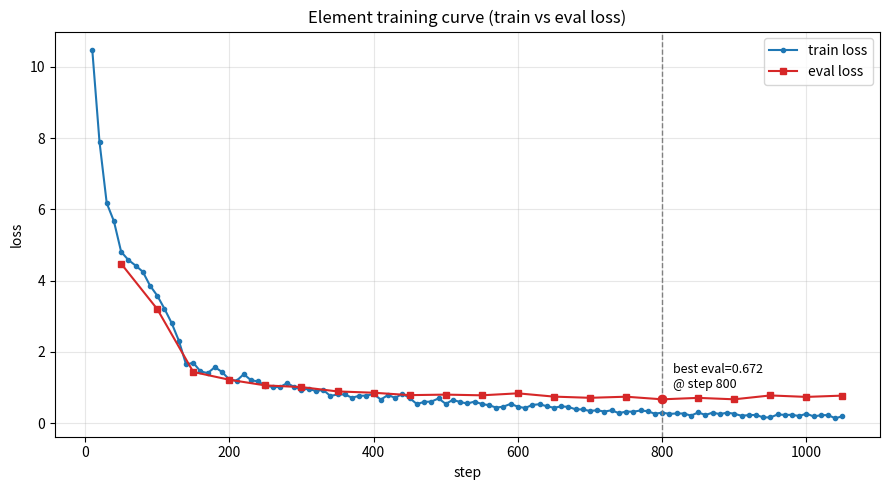

final train loss : 0.199
best  eval  loss : 0.672 @ step 800
final eval  loss : 0.776
=> Overfitting likely: train << eval (gap 0.58), eval rose after best, best is before the end.


In [18]:
# ── 학습 곡선: train_loss vs eval_loss (과적합 점검) ──────────────
# 학습 직후 실행하세요. train은 계속 내려가는데 eval이 정체/상승하면 과적합 신호입니다.
# trainer가 메모리에 있으면 그 로그를, 없으면(커널 재시작) 최신 체크포인트의 로그를 사용합니다.
import os, glob, json
from pathlib import Path
import matplotlib.pyplot as plt


def load_log_history():
    """trainer.state.log_history 우선, 없으면 최신 checkpoint-*/trainer_state.json."""
    if "trainer" in globals() and getattr(trainer, "state", None) is not None:
        return trainer.state.log_history
    out = CFG["training"]["output_dir"] if "CFG" in globals() else "../checkpoints_elements"
    ckpts = sorted(glob.glob(os.path.join(out, "checkpoint-*")),
                   key=lambda p: int(p.split("-")[-1]))
    if not ckpts:
        raise FileNotFoundError(f"No log history (trainer 없음, {out}에 checkpoint도 없음).")
    state = json.load(open(os.path.join(ckpts[-1], "trainer_state.json"), encoding="utf-8"))
    return state.get("log_history", [])


log   = load_log_history()
train = [(e["step"], e["loss"])      for e in log if "loss" in e and "eval_loss" not in e]
evals = [(e["step"], e["eval_loss"]) for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(9, 5))
if train:
    ax.plot(*zip(*train), "o-", color="tab:blue", markersize=3, label="train loss")
if evals:
    ax.plot(*zip(*evals), "s-", color="tab:red", markersize=4, label="eval loss")
    best_step, best_eval = min(evals, key=lambda x: x[1])
    ax.axvline(best_step, ls="--", color="gray", lw=1)
    ax.scatter([best_step], [best_eval], color="tab:red", zorder=5)
    ax.annotate(f"best eval={best_eval:.3f}\n@ step {best_step}", (best_step, best_eval),
                textcoords="offset points", xytext=(8, 8), fontsize=9)
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Element training curve (train vs eval loss)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

OUT = Path("output") / "loss_curve_elements.png"
OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT, dpi=150)
print(f"Saved loss curve -> {OUT.resolve()}")
plt.show()

# ── 과적합 간단 진단 ─────────────────────────────────────────────
if train and evals:
    final_train          = train[-1][1]
    best_step, best_eval = min(evals, key=lambda x: x[1])
    final_eval           = evals[-1][1]
    last_step            = evals[-1][0]
    print(f"final train loss : {final_train:.3f}")
    print(f"best  eval  loss : {best_eval:.3f} @ step {best_step}")
    print(f"final eval  loss : {final_eval:.3f}")
    gap   = final_eval - final_train
    rose  = final_eval > best_eval + 1e-3
    early = best_step < last_step
    if gap > 0.2 and (rose or early):
        print(f"=> Overfitting likely: train << eval (gap {gap:.2f})"
              f"{', eval rose after best' if rose else ''}"
              f"{', best is before the end' if early else ''}.")
    else:
        print(f"=> Weak overfitting signal (gap {gap:.2f}).")

## Step 5 – 평가 (Evaluation)

**Leaf-Match Score**: 예측 JSON과 정답 JSON의 모든 리프(leaf) 값을 비교하여 일치율을 계산합니다.  
(완전한 TED 구현을 원하면 `zss` 패키지를 사용하세요)

In [19]:
# ── Step 5a: 평가 유틸리티 ────────────────────────────────────────

def token2json(tokens: str) -> dict | str:
    '''모델이 생성한 토큰 시퀀스를 Python dict로 역변환.

    json2token()의 반대 과정입니다.
    예) "<s_total>12500</s_total>" → {"total": "12500"}

    정규표현식으로 <s_key>...</s_key> 패턴을 찾아 재귀적으로 파싱합니다.
    '''
    output = {}
    while tokens:
        # 여는 태그 <s_key> 탐색
        start = re.search(r"<s_(.+?)>", tokens)
        if not start:
            break
        key     = start.group(1)
        end_pat = f"</s_{key}>"
        end_pos = tokens.find(end_pat, start.end())
        if end_pos == -1:
            break
        value = tokens[start.end():end_pos]
        # 값 안에 중첩 태그가 있으면 재귀 호출로 파싱
        output[key] = token2json(value) if "<s_" in value else value.strip()
        tokens = tokens[end_pos + len(end_pat):]
    return output if output else tokens.strip()


def compute_leaf_match(pred: dict, gt: dict) -> float:
    '''예측 JSON과 정답 JSON의 최말단(leaf) 값 일치율을 계산합니다 (0~1).

    중첩 구조를 평탄화(flatten)한 뒤 경로별로 값을 비교합니다.
    예) {"menu": {"nm": "Burger"}} → {"/menu/nm": "Burger"}
    전체 정답 leaf 중 예측이 맞춘 비율을 반환합니다.
    '''
    def flatten(d, prefix=""):
        items = {}
        if isinstance(d, dict):
            for k, v in d.items():
                items.update(flatten(v, f"{prefix}/{k}"))
        elif isinstance(d, list):
            for i, v in enumerate(d):
                items.update(flatten(v, f"{prefix}[{i}]"))
        else:
            items[prefix] = str(d)
        return items

    pred_flat = flatten(pred)
    gt_flat   = flatten(gt)
    if not gt_flat:
        return 1.0 if not pred_flat else 0.0
    matches = sum(pred_flat.get(k) == v for k, v in gt_flat.items())
    return matches / len(gt_flat)  # 일치한 leaf 수 / 전체 정답 leaf 수

print("평가 유틸리티 정의 완료 ✓")


평가 유틸리티 정의 완료 ✓


In [20]:
# ── Step 5b: Validation set 전체 평가 ────────────────────────────
# ※ 학습이 완료된 뒤 실행하세요.
# 저장된 체크포인트를 로드하고 검증 데이터 전체에 추론 → Leaf-Match Score 계산.

CHECKPOINT     = os.path.join(CFG["training"]["output_dir"], "final")
MAX_NEW_TOKENS = CFG["model"]["max_length"]   # 학습 max_length(128)와 동일하게
EVAL_BATCH     = 1

# 저장된 체크포인트가 있으면 로드, 없으면 현재 메모리의 model 사용
if os.path.isdir(CHECKPOINT):
    eval_processor = DonutProcessor.from_pretrained(CHECKPOINT)
    eval_model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT).to(device)
else:
    print(f"체크포인트 없음: {CHECKPOINT} — 현재 model 사용")
    eval_model, eval_processor = model, processor

eval_model.eval()

task_prompt = CFG["data"]["task_prompt"]
decoder_input_ids = eval_processor.tokenizer(
    task_prompt, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

def _clean(seq: str) -> str:
    # 특수 토큰(BOS/EOS/PAD)과 task 토큰 제거 → token2json이 본문만 파싱하도록.
    # (task 토큰을 안 떼면 닫힘 태그 없는 키로 오인해 파싱 실패 → 점수가 0이 됨)
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task_prompt):
        if t:
            seq = seq.replace(t, "")
    return seq.strip()

val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH, shuffle=False, num_workers=2)

scores = []
with torch.inference_mode():
    for batch in tqdm(val_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        outputs = eval_model.generate(
            pixel_values,
            decoder_input_ids = decoder_input_ids.expand(pixel_values.size(0), -1),
            max_new_tokens    = MAX_NEW_TOKENS,
            pad_token_id      = eval_processor.tokenizer.pad_token_id,
            eos_token_id      = eval_processor.tokenizer.eos_token_id,
            use_cache         = True,
        )
        for i, seq in enumerate(outputs):
            pred_str = _clean(eval_processor.batch_decode([seq], skip_special_tokens=False)[0])
            gt_str   = _clean(batch["target_sequence"][i])
            pred_json, gt_json = token2json(pred_str), token2json(gt_str)
            if isinstance(pred_json, dict) and isinstance(gt_json, dict):
                scores.append(compute_leaf_match(pred_json, gt_json))
            else:
                scores.append(1.0 if pred_str == gt_str else 0.0)

mean_score = sum(scores) / len(scores) if scores else 0.0
print(f"\n평가 완료 — {len(scores)} 샘플")
print(f"Leaf-Match Score: {mean_score:.4f} ({mean_score*100:.2f}%)")
print("  (1.0 = 모든 필드 완벽 일치 / 0.0 = 전혀 불일치)")


Evaluating: 100%|██████████| 197/197 [00:27<00:00,  7.26it/s]


평가 완료 — 197 샘플
Leaf-Match Score: 0.0102 (1.02%)
  (1.0 = 모든 필드 완벽 일치 / 0.0 = 전혀 불일치)


## Step 6 – 추론 (Inference)

이미지 파일 한 장을 넣으면 JSON 결과를 반환합니다.

추론 모델 로드 완료 → ../checkpoints_elements/final

입력: ../data/processed_elements/val/images/1467_t45_f013_s19_Datu.png
추론 결과:
"<s_Datum> A"


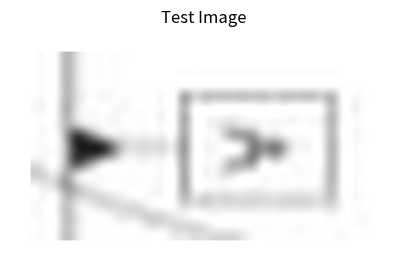

In [29]:
# ── Step 6: 단일 이미지 추론 ──────────────────────────────────────
# 학습된 모델을 체크포인트(checkpoints_elements/final)에서 "직접 로드"해 추론합니다.
# → Step 5b 평가를 건너뛰어도 이 셀만으로 동작합니다.
import os, glob, re

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = os.path.join(CFG["training"]["output_dir"], "final")   # = checkpoints_elements/final
assert os.path.isdir(CKPT_DIR), f"체크포인트 없음: {CKPT_DIR} — 먼저 Step 4 학습을 실행하세요."

# 학습 결과(모델 + 프로세서)를 로드
eval_processor = DonutProcessor.from_pretrained(CKPT_DIR)
eval_model     = VisionEncoderDecoderModel.from_pretrained(CKPT_DIR).to(device).eval()
print(f"추론 모델 로드 완료 → {CKPT_DIR}")

# token2json(Step 5a)이 없을 때를 대비한 폴백 정의 (Step 5a를 안 돌렸어도 동작)
if "token2json" not in globals():
    def token2json(tokens):
        output = {}
        while tokens:
            start = re.search(r"<s_(.+?)>", tokens)
            if not start:
                break
            key = start.group(1); end_pat = f"</s_{key}>"
            end_pos = tokens.find(end_pat, start.end())
            if end_pos == -1:
                break
            value = tokens[start.end():end_pos]
            output[key] = token2json(value) if "<s_" in value else value.strip()
            tokens = tokens[end_pos + len(end_pat):]
        return output if output else tokens.strip()


@torch.inference_mode()
def predict(image_path: str, task: str | None = None) -> dict:
    """이미지 경로 → 추출 정보(dict). task가 None이면 CFG의 task_prompt 사용."""
    task = task or CFG["data"]["task_prompt"]
    image        = Image.open(image_path).convert("RGB")
    pixel_values = eval_processor(image, return_tensors="pt").pixel_values.to(device)
    decoder_ids  = eval_processor.tokenizer(
        task, add_special_tokens=False, return_tensors="pt"
    ).input_ids.to(device)

    outputs = eval_model.generate(
        pixel_values,
        decoder_input_ids = decoder_ids,
        max_new_tokens    = CFG["model"]["max_length"],
        pad_token_id      = eval_processor.tokenizer.pad_token_id,
        eos_token_id      = eval_processor.tokenizer.eos_token_id,
        use_cache         = True,
        # ── 반복억제(퇴화 반복 방지) ──────────────────────────────
        # 약한/과적합 디코더가 greedy 로 같은 토큰("0000…", "- 1 - 1 …")을
        # 자기강화 반복하며 EOS 를 못 내는 현상을 막는다.
        #  no_repeat_ngram_size : 같은 3-gram 재등장 금지(반복 루프 차단)
        #  repetition_penalty   : 이미 나온 토큰의 logit 을 낮춰 재선택 억제(>1.0)
        # ※ 증상(반복/비종료) 치료일 뿐 값 정확도를 올리진 않는다 → 데이터/학습 개선은 별개.
        no_repeat_ngram_size = 3,
        repetition_penalty   = 1.5,
    )

    # 토큰 ID → 문자열 → (BOS/EOS/PAD/task 토큰 제거) → dict
    sequence = eval_processor.batch_decode(outputs, skip_special_tokens=False)[0]
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task):
        if t:
            sequence = sequence.replace(t, "")
    return token2json(sequence.strip())


# ── 데모: 검증셋 첫 이미지로 추론 ────────────────────────────────
val_dir = os.path.join(CFG["data"]["local_val_dir"], "images")
cands   = sorted(glob.glob(os.path.join(val_dir, "*")))
if not cands:                       # 폴백: 원본 도면 폴더
    cands = sorted(glob.glob("../data/elements/images/*"))
test_image_path = cands[11]

result = predict(test_image_path)
print(f"\n입력: {test_image_path}")
print("추론 결과:")
print(json.dumps(result, indent=2, ensure_ascii=False))

# 이미지 시각화
fig, ax = plt.subplots(figsize=(5, 8))
ax.imshow(Image.open(test_image_path).convert("RGB"))
ax.axis("off"); ax.set_title("Test Image")
plt.show()


## 추론 결과를 JSON 형식으로 출력

모델이 생성한 **원시 토큰 문자열**(raw output)을 정리 → dict → 보기 좋은 JSON 문자열로 변환합니다.

> ⚠️ **학습이 부족하면** 토큰 구조가 깨져(예: `<___read>`, `<s/_read>`) 정상 JSON이 나오지 않습니다.
> 이 경우 아래 함수는 파싱 가능한 부분만 JSON으로 만들고, 실패하면 `_raw`에 원문을 담아 안전하게 보여줍니다.
> **깨진 출력 자체를 고치려면 파서가 아니라 추가 학습이 필요합니다.**


In [28]:
# ── 추론 결과 → JSON 변환/출력 ──────────────
# 모델 원시 출력 문자열을 받아 JSON 문자열로 변환합니다.
# token2json(Step 5a) · eval_processor(Step 5b/6)가 먼저 정의돼 있어야 합니다.
import json, re

def output_to_json(raw: str, task_prompt: str = None, indent: int = 2) -> str:
    """모델 원시 출력 문자열 → JSON 문자열.

    1) 특수 토큰(BOS/EOS/PAD)과 task 토큰 제거
    2) token2json으로 <s_key>...</s_key> 구조를 dict로 파싱
    3) 파싱 실패(구조 손상) 시 {"_raw": ...}로 원문을 감싸 반환
    """
    task_prompt = task_prompt or CFG["data"]["task_prompt"]
    s = raw
    # strip 대상 = 다른 호출부(read_value/predict/_clean)와 동일한 (eos/pad/bos/task) 집합.
    # (eval_processor 미정의 시에도 최소한 task 토큰은 떼도록 try/except 로 감쌈)
    try:
        special = (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
                   eval_processor.tokenizer.bos_token, task_prompt)
    except Exception:
        special = (task_prompt,)
    for t in special:
        if t:
            s = s.replace(t, "")
    s = s.strip()

    parsed = token2json(s)
    if not isinstance(parsed, dict) or not parsed:
        parsed = {"_raw": raw.strip(),
                  "_note": "토큰 구조가 불완전합니다 — 학습 부족일 수 있습니다."}
    return json.dumps(parsed, indent=indent, ensure_ascii=False)


# ── 사용법 A) 모델 원시 출력 문자열을 직접 변환 ──────────────
# generate() 직후 batch_decode로 얻은 문자열을 그대로 넣으세요.
raw_output = "<s_element><s_dimension>Ø65</s_dimension></s_element>"
print(output_to_json(raw_output))

# ── 사용법 B) 이미지로 추론한 결과를 JSON으로 출력 ──────────────
# predict()는 dict를 반환하므로 그대로 json.dumps. (하드코딩 대신 검증셋 첫 크롭 사용)
import glob
_cands = (sorted(glob.glob(os.path.join(CFG["data"]["local_val_dir"], "images", "*")))
          or sorted(glob.glob("../data/elements/images/*")))
if _cands:
    print(_cands[0])
    print(json.dumps(predict(_cands[0]), indent=2, ensure_ascii=False))
else:
    print("element 크롭이 아직 없습니다 — 데이터 준비/학습 후 실행하세요")


{
  "dimension": "Ø65"
}
../data/processed_elements/val/images/1375_t45_f001_s01_Dime.png
"<s_Dimension>Ø.5 +0 - 01"


### (선택) 태그 없이 깔끔하게 출력

파싱 결과(dict)의 값에 `</s_...>`·`<sep/>` 같은 **잔여 태그**가 섞여 있으면 제거하고 보여줍니다.
(학습이 잘 되면 보통 깨끗하지만, 불완전 출력일 때 유용)


In [17]:
# ── 태그 제거 후 출력 ──────────────
import re, json
from pprint import pprint

def strip_tags(o):
    """dict/list/str 안의 <...> 태그(<s_..>, </s_..>, <sep/>)를 모두 제거"""
    if isinstance(o, dict):
        return {k: strip_tags(v) for k, v in o.items()}
    if isinstance(o, list):
        return [strip_tags(v) for v in o]
    if isinstance(o, str):
        return re.sub(r"<[^>]*>", "", o).strip()
    return o

clean = strip_tags(result)   # result = Step 6 / 위 셀의 predict() 결과
print(json.dumps(clean, indent=2, ensure_ascii=False))   # 한글 유지 — JSON 권장
# pprint(clean, indent=2, width=80, compact=False)        # pprint를 원하면 이 줄 사용

# <sep/>를 구분 기호로 살리고 싶으면 strip_tags의 re.sub를 아래로 교체:
#   return re.sub(r"<(?!sep/>)[^>]*>", "", o).replace("<sep/>", ", ").strip()


{
  "Dimension": "S.0"
}


---
## Element 파인튜닝 체크리스트 & 트러블슈팅

### 실행 순서 요약
1. **Step 0 ~ 공통 import** 실행
2. **Step 1 (CFG)** — 그대로 실행 (element 용으로 이미 설정됨)
3. **라벨 점검** — 빈 값 비율 확인, 가능한 한 라벨을 채운다
4. **데이터 분리** — `data/processed_elements/{train,val}` 생성 (`cvat_to_donut.py` → split 셀)
5. **Step 2 ~ 3** — 모델/데이터셋 로드 (`<s_element>` + 타입 토큰 자동 추가 확인)
6. **Step 4** — 학습 (`checkpoints_elements/`에 저장)
7. **Step 5 ~ 6** — 평가 및 추론

### 자주 겪는 문제
| 증상 | 원인 | 해결 |
|------|------|------|
| 출력이 빈 값/엉뚱한 값 | 라벨에 빈 값이 많음, 데이터 부족 | 라벨 채우기, 데이터 추가, 에폭↑ |
| `eval_loss`가 다시 증가 | 과적합 (데이터 적을 때 흔함) | `EarlyStoppingCallback`이 조기 종료 + `load_best_model_at_end`가 best 복원 / 데이터↑ |
| 작은 글자 인식 실패 | 입력 해상도 부족 | `image_size`를 키움 (VRAM↑) |
| CUDA out of memory | 배치/해상도 과다 | `batch_size=1`, `gradient_accumulation_steps`↑ |
| 생성이 중간에 잘림 | `max_length` 부족 | `max_length`↑ (element 값은 짧아 128 로 충분) |

### 데이터 양에 따른 권장 설정
- ~50장: `num_epochs 100`, 과적합 주의, 결과는 PoC 수준
- 수백 장: `num_epochs 50~80`
- 수천 장: `num_epochs 10~30`

> 핵심은 **라벨 품질과 스키마 일관성**입니다. 모든 라벨 JSON의 키 구조를 동일하게 유지하세요.
